## Main code

In [88]:
! # Make sure to enable the ipycanvas/ other widgets
!jupyter labextension enable widgetsnbextension

In [219]:
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import squidpy as sq

from popari.io import save_anndata, load_anndata

from popari.simulation_framework import MultiReplicateSyntheticDataset, SyntheticDataset, SimulationParameters

from pathlib import Path

import matplotlib.pyplot as plt
import random
import seaborn as sns

In [220]:
from importlib import reload
from popari import simulation_framework
reload(simulation_framework)
from popari.simulation_framework import MultiReplicateSyntheticDataset, SyntheticDataset, SimulationParameters

In [221]:
from popari.io import save_anndata, load_anndata
from popari.components import PopariDataset
from popari._dataset_utils import _plot_all_embeddings, _plot_in_situ, _multireplicate_heatmap, _compute_empirical_correlations

In [222]:
cell_type_definitions = {
    "Excitatory L1":         [0.5, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    "Excitatory L2":         [0.5, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    "Excitatory L3":         [0.5, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    "Excitatory L4":         [0.5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    "Inhibitory L1":         [0, 0.5, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    "Inhibitory L2":         [0, 0.5, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    "Inhibitory L3":         [0, 0.5, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    "Inhibitory L4":         [0, 0.5, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    "Non-Neuron Ubiquitous": [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
}
progenitor_distributions = {
    "L1": {
        "Excitatory L1": 0.53,
        "Inhibitory L1": 0.2,
        "Inhibitory L2": 0.2,
        "Non-Neuron Ubiquitous": 0.07,
    },
    "L2": {
        "Excitatory L2": 0.53,
        "Inhibitory L2": 0.2,
        "Inhibitory L3": 0.2,
        "Non-Neuron Ubiquitous": 0.07,
    },
    "L3": {
        "Excitatory L3": 0.53,
        "Inhibitory L3": 0.2,
        "Inhibitory L4": 0.2,
        "Non-Neuron Ubiquitous": 0.07,
    },
    "L4": {
        "Excitatory L4": 0.53,
        "Inhibitory L3": 0.2,
        "Inhibitory L4": 0.2,
        "Non-Neuron Ubiquitous": 0.07,
    },
}

layer_distributions = {
    "L1": {
        "Excitatory L1": 0.2,
        "Excitatory L2": 0.2,
        "Inhibitory L1": 0.53,
        "Non-Neuron Ubiquitous": 0.07,
    },
    "L2": {
        "Excitatory L2": 0.2,
        "Excitatory L3": 0.2,
        "Inhibitory L2": 0.53,
        "Non-Neuron Ubiquitous": 0.07,
    },
    "L3": {
        "Excitatory L3": 0.2,
        "Excitatory L4": 0.2,
        "Inhibitory L3": 0.53,
        "Non-Neuron Ubiquitous": 0.07,
    },
    "L4": {
        "Excitatory L3": 0.2,
        "Excitatory L4": 0.2,
        "Inhibitory L4": 0.53,
        "Non-Neuron Ubiquitous": 0.07,
    },
}

metagene_variation_probabilities = [0, 0.1, 0, 0, 0.1, 0.1, 0.1, 0, 0.1, 0.1, 0.1]

shared_parameters = {
    'num_genes': 100,
    'annotation_mode': 'domain',
    'num_real_metagenes': 11,
    'num_noise_metagenes': 0,
    'sig_y_scale': 1.0,
    'sig_x_scale': 1.0,
    'real_metagene_parameter': 8.0,
    'noise_metagene_parameter': 4.0,
    'lambda_s': 1.,
    'width': 1,
    'height': 1,
    'grid_size': 15,
    'metagene_variation_probabilities': metagene_variation_probabilities,
    'cell_type_definitions': cell_type_definitions,
    'domain_key': 'domain',
}

progenitor_parameters = SimulationParameters(
    **shared_parameters,
    spatial_distributions=progenitor_distributions,
)

layer_parameters = SimulationParameters(
    **shared_parameters,
    spatial_distributions=layer_distributions,
)

num_copies = 5
duplicated_parameters = [
    {
        f"progenitor_{index}": progenitor_parameters,
        f"layer_{index}": layer_parameters,
    }
    for index in range(num_copies)
]
replicate_parameters = {replicate_name: parameters for replicate_parameters in duplicated_parameters for replicate_name, parameters in replicate_parameters.items()}

In [223]:
multireplicate_dataset = MultiReplicateSyntheticDataset(replicate_parameters, SyntheticDataset, random_state=101, verbose=0, percent_batch_effect=1.0)

In [227]:
multireplicate_dataset.annotate_replicate_domain("layer_0")

Annotating replicate layer_0


Choose a domain to annotate (enter an integer):
0: L1
1: L2
2: L3
3: L4
 3


Output()

Canvas(height=600, image_data=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02X\x00\x00\x02X\x08\x06\x00\x00\…

In [228]:
layer_domains = multireplicate_dataset.datasets["layer_0"].domain_canvas.domains

for i in range(5):
   multireplicate_dataset.datasets[f"progenitor_{i}"].domain_canvas.load_domains(layer_domains)
   multireplicate_dataset.datasets[f"layer_{i}"].domain_canvas.load_domains(layer_domains) 

In [229]:
multireplicate_dataset.assign_domain_labels()

In [230]:
# # Same parameters for each replicate (for now)
# replicate_simulation_parameters = {}
# for i in range(5):
#     replicate_simulation_parameters.update({
#         f"progenitor_{i}": simulation_parameters,
#         f"layer_{i}": simulation_parameters
#     })

multireplicate_dataset.simulate_expression()

In [231]:
for dataset in multireplicate_dataset:
    print("batch_effect", dataset.uns["batch_effect"][dataset.name])
    print("ground truth", dataset.obsm["ground_truth_X"][0])

batch_effect [1.64393251e+03 1.72099014e+04 7.35864923e+03 3.81702753e+03
 5.65337099e+03 3.65797668e+02 4.59773408e+03 1.26847329e+04
 1.82650726e+04 3.98848239e+03 1.65067981e+01]
ground truth [1.64393251e+03 1.72138267e+04 7.35864923e+03 3.82839338e+03
 5.65337099e+03 3.65797668e+02 4.59773408e+03 1.26847329e+04
 1.82650726e+04 3.98848239e+03 1.65067981e+01]
batch_effect [14830.26477874  5613.17579726 20715.90770865  6504.10294269
    65.21421231 16832.43769712  7024.80267977  3044.4131058
  4461.38192134   830.66932768  6124.9273554 ]
ground truth [14830.26477874  5616.16532593 20715.90770865  6508.90088916
    65.21421231 16832.43769712  7024.80267977  3044.4131058
  4461.38192134   830.66932768  6124.9273554 ]
batch_effect [15441.61654573  2763.00195764 12662.64969494  4318.96752056
 11906.35091956 16376.99503507  2725.11332099  5727.09663871
  1097.56112575  4768.83006361 18923.53581463]
ground truth [15445.63964089  2763.00195764 12662.64969494  4318.96752056
 11906.35091956 16

In [232]:
multireplicate_dataset.calculate_neighbors(coord_type="grid", n_neighs=4, delaunay=False)

In [233]:
def sample_graph_iid(adjacency_list, indices_remaining, sample_size):                              
    valid_indices = []                                                                             
    excluded_indices = set()                                                                       
    effective_batch_size = min(sample_size, len(indices_remaining))                                
    candidate_indices = np.random.choice(list(indices_remaining),                                  
        size=effective_batch_size,                                                                 
        replace=False,                                                                             
    )                                                                                              
    for index in candidate_indices:                                                                
        if index not in excluded_indices:                                                                                                                                                                                                                                       
            valid_indices.append(index)                                                            
            excluded_indices |= set(adjacency_list[index])                                         
                                                                                                   
    return valid_indices   

def adjacency_matrix_to_list(adjacency_matrix):
    """
    """
    adjacency_matrix = adjacency_matrix.tocoo()                                

    num_cells, _ = adjacency_matrix.shape                                                      
    adjacency_list = [[] for _ in range(num_cells)]                                                                                                                                                                                                                         
    for x, y in zip(*adjacency_matrix.nonzero()):                                              
        adjacency_list[x].append(y)                                                            

    return adjacency_list   

In [234]:
# # Actually spatial downsampling
# # Only handles sparsity up to a certain level, due to method of choosing independent set

# rng = np.random.default_rng(seed=0)
# sparsity = 0.08
# for name, dataset in multireplicate_dataset.datasets.items():
#     num_cells, num_genes = dataset.shape
#     num_dropout_cells = np.rint(sparsity * num_cells).astype(int)
    
#     adjacency_list = adjacency_matrix_to_list(dataset.obsp["adjacency_matrix"])
    
#     for gene_index in range(num_genes):
#         independent_set = sample_graph_iid(adjacency_list, set(range(num_cells)), num_cells)
    
#         dropout_cells = independent_set[:num_dropout_cells]
#         dataset.X[dropout_cells, gene_index] = 0

In [235]:
(replicate_names, datasets) = zip(*multireplicate_dataset.datasets.items())

         Falling back to preprocessing with `sc.pp.pca` and default params.


/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


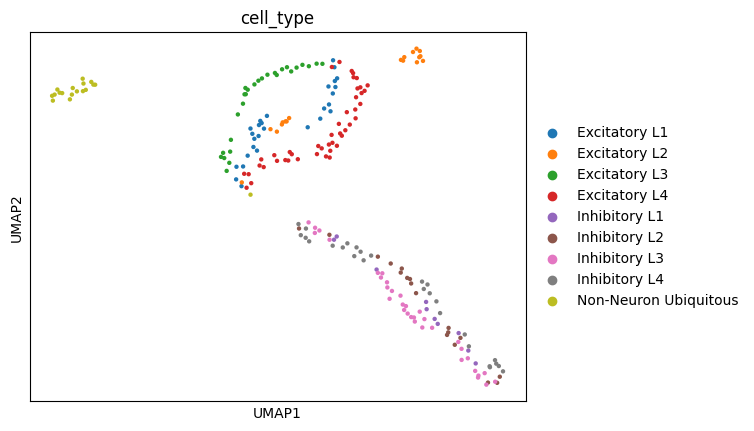

In [236]:
fig, ax = plt.subplots()
sc.pp.neighbors(datasets[0])
sc.tl.umap(datasets[0])
sc.pl.umap(datasets[0], color="cell_type", ax=ax, size=40)

/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


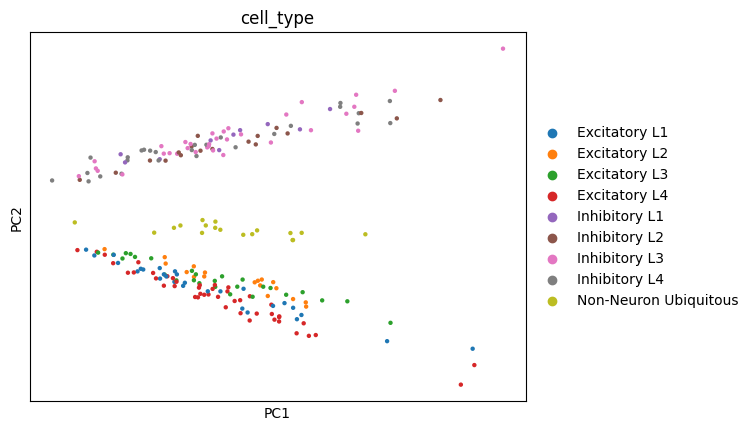

In [237]:
fig, ax = plt.subplots()
sc.tl.pca(datasets[0])
sc.pl.pca(datasets[0], color="cell_type", ax=ax, size=40)

In [238]:
from popari.util import concatenate

         Falling back to preprocessing with `sc.pp.pca` and default params.


/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a

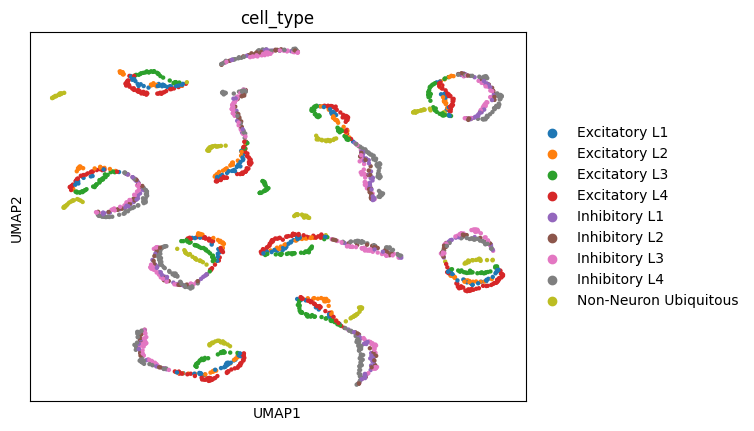

In [239]:
replicate_names, dataset_copies = zip(*multireplicate_dataset.datasets.items())
merged_dataset = concatenate(dataset_copies)                                                                                                                                        
fig, ax = plt.subplots()
sc.pp.neighbors(merged_dataset)
sc.tl.umap(merged_dataset)
sc.pl.umap(merged_dataset, color="cell_type", ax=ax, size=40)

/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


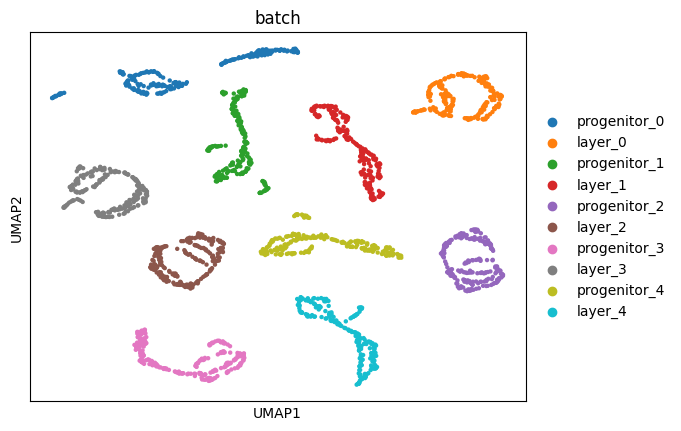

In [240]:
fig, ax = plt.subplots()
sc.pl.umap(merged_dataset, color="batch", ax=ax, size=40)

In [241]:
from popari.util import unconcatenate
datasets = unconcatenate(merged_dataset)
for dataset in datasets:
    print("batch_effect", dataset.uns["batch_effect"][dataset.name])
    print("ground truth", dataset.obsm["ground_truth_X"][0])

batch_effect [1.64393251e+03 1.72099014e+04 7.35864923e+03 3.81702753e+03
 5.65337099e+03 3.65797668e+02 4.59773408e+03 1.26847329e+04
 1.82650726e+04 3.98848239e+03 1.65067981e+01]
ground truth [1.64393251e+03 1.72138267e+04 7.35864923e+03 3.82839338e+03
 5.65337099e+03 3.65797668e+02 4.59773408e+03 1.26847329e+04
 1.82650726e+04 3.98848239e+03 1.65067981e+01]
batch_effect [14830.26477874  5613.17579726 20715.90770865  6504.10294269
    65.21421231 16832.43769712  7024.80267977  3044.4131058
  4461.38192134   830.66932768  6124.9273554 ]
ground truth [14830.26477874  5616.16532593 20715.90770865  6508.90088916
    65.21421231 16832.43769712  7024.80267977  3044.4131058
  4461.38192134   830.66932768  6124.9273554 ]
batch_effect [15441.61654573  2763.00195764 12662.64969494  4318.96752056
 11906.35091956 16376.99503507  2725.11332099  5727.09663871
  1097.56112575  4768.83006361 18923.53581463]
ground truth [15445.63964089  2763.00195764 12662.64969494  4318.96752056
 11906.35091956 16